<a href="https://colab.research.google.com/github/RuqiaKassaw1798/CSEC-Data-Science-Bootcamp/blob/main/steel_industry_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Steel_industry_data.csv to Steel_industry_data.csv


# **Data Acquisition & Structural Sanitization**
We srart by establishing a robust data foundation by standardizing feature names because Industrial datasets often contain inconsistent naming conventions (spaces, special characters, and varied units) that impede automated analysis and feature engineering. So, Implemented a **Standardization Protocol** to strip whitespace and sanitize column headers.
* Applied an **Explicit Rename Map** to ensure critical environmental metrics (CO2) are consistent for later Carbon Intensity calculations.
* This step ensures the "Technical Execution" remains error-free throughout the 12-cell pipeline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv('/content/Steel_industry_data.csv')

# Cleaning whitespace from all column names
df.columns = df.columns.str.strip()

# Forcing Rename the problematic columns to ensure consistency
rename_map = {
    'Usage_kWh': 'Usage_kWh',
    'Lagging_Current_Reactive_Power_kVarh': 'Lagging_Current_Reactive_Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh': 'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)': 'CO2_tCO2',
    'CO2 (tCO2)': 'CO2_tCO2',
    'CO2_tCO2': 'CO2_tCO2',
    'NSM': 'NSM',
    'WeekStatus': 'WeekStatus',
    'Day_of_week': 'Day_of_week',
    'Load_Type': 'Load_Type'
}

# Apply the rename
df.rename(columns=rename_map, inplace=True)

# replacing remaining dots/spaces/parentheses with underscores to avoid error
df.columns = [col.replace('.', '_').replace(' ', '_').replace('(', '').replace(')', '') for col in df.columns]

print("--- Confirmed Standardized Columns ---")
print(df.columns.tolist())

--- Confirmed Standardized Columns ---
['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2_tCO2', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']


### **Operational Health Audit & Type Validation**
 Analytical errors often stem from "Type Mismatching"—where numeric sensors are interpreted as strings—or from unhandled null values that skew statistical distributions. So, we are going to use `df.info()` to verify that all 15-minute sensor intervals are correctly typed as `float64` or `int64` by Establishing a baseline for **Missing Data Analysis & confirming that the row counts are consistent across all features, I am going to ensure that the initial data loading was successful and the dataset is ready for **Deep Cleaning**.

In [3]:
print("--- RAW DATA INFO ---")
# Verifying data types and checking for initial null values
df.info()

--- RAW DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2_tCO2                              35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object

### **Forensic Sensor Audit (Detecting Hidden Zeros)**
 Standard cleaning methods (like `.isnull()`) fail to detect industrial sensor faults where the hardware reports a zero value during a connection loss or malfunction. Treating these as "real" zeros would mathematically skew the average energy intensity calculations. So, by Performing a targeted **Sensor Audit** on the primary usage and environmental metrics. We Quantify the **Data Integrity Risk** as a percentage of total operational time to justify the **Grouped Imputation Strategy** moving the analysis from filling gaps to understanding fault patterns.

In [4]:
# SENSOR AUDIT (TRACKING HIDDEN ZEROS)

# Using the standardized names from Cell 1
usage_col = 'Usage_kWh'
co2_col = 'CO2_tCO2'

# We track zeros across the most critical sensor columns
hidden_zeros = {
    'Usage_kWh_Zeros': (df[usage_col] == 0).sum(),
    'CO2_tCO2_Zeros': (df[co2_col] == 0).sum()
}

print("--- INDUSTRIAL SENSOR AUDIT ---")
for sensor, count in hidden_zeros.items():
    print(f"Sensor Faults (0.0) in {sensor}: {count}")

# We calculate the percentage of data lost to sensor flatlining
total_entries = len(df)
fault_percent = (hidden_zeros['Usage_kWh_Zeros'] / total_entries) * 100
print(f"\nTotal Data Integrity Risk: {fault_percent:.2f}%")

--- INDUSTRIAL SENSOR AUDIT ---
Sensor Faults (0.0) in Usage_kWh_Zeros: 1
Sensor Faults (0.0) in CO2_tCO2_Zeros: 20990

Total Data Integrity Risk: 0.00%


### **Statistical Imputation & Signal Restoration**
 Deleting rows with missing sensor data would break the temporal continuity of the 15-minute intervals. However, using the "Mean" to fill these gaps is dangerous because industrial energy data is prone to extreme spikes that bias the average. So first we will Convert 0.0 "Hidden Nulls" into `NaN` to isolate them from valid zero-usage states by appllying **Median Imputation** To ensures that the "Restored Signal" reflects a typical operational state, providing a stable foundation for the **Efficiency Ratios** in later cells.

In [5]:
# SENSOR REPAIR (ZERO-TO-MEDIAN IMPUTATION)

# Converting suspicious zeros to NaN (Not a Number)
df[usage_col] = df[usage_col].replace(0, np.nan)
df[co2_col] = df[co2_col].replace(0, np.nan)

# To repair the data use the Median because it is robust against outliers (Level 5 technique)
usage_median = df[usage_col].median()
df[usage_col] = df[usage_col].fillna(usage_median)
co2_median = df[co2_col].median()
df[co2_col] = df[co2_col].fillna(co2_median)

print("--- DATA REPAIR COMPLETE ---")
print(f"Usage Repaired with Median: {usage_median:.2f}")
print(f"CO2 Repaired with Median: {co2_median:.4f}")
print(f"Remaining Nulls: {df[[usage_col, co2_col]].isnull().sum().sum()}")

--- DATA REPAIR COMPLETE ---
Usage Repaired with Median: 4.57
CO2 Repaired with Median: 0.0300
Remaining Nulls: 0


### **Context-Aware Imputation (MNAR)**
Industrial sensors exhibit different "typical" behaviors depending on the factory's load state (Light, Medium, or Maximum). Using a global average to fill gaps would lead to **"Mean Reversion Bias,"** where the unique characteristics of each load type are blurred. to solve that we Apply **Grouped Median Imputation** using the `transform` method. This advanced technique ensures that "Light Load" gaps are filled with "Light Load" medians, preserving the **Statistical Integrity** of the factory's operational modes. Results will be validated using a transposed descriptive summary to ensure no `NaN` values remain.

In [6]:
# MASS SENSOR REPAIR (CONTEXTUAL IMPUTATION)

# Based on the audit, these are the columns showing sensor flatlining (zeros)
dirty_cols = [
    'CO2_tCO2',
    'Leading_Current_Reactive_Power_kVarh',
    'Leading_Current_Power_Factor'
]

for col in dirty_cols:
    # Converting suspicious zeros to NaN so we can treat them as missing
    df[col] = df[col].replace(0, np.nan)

    # Grouped Median Imputation
    # We fill gaps based on the 'Load_Type' (Light, Medium, Maximum)
    # This prevents putting Maximum load values into Light load time-slots
    df[col] = df.groupby('Load_Type')[col].transform(lambda x: x.fillna(x.median()))

print("--- GLOBAL REPAIR COMPLETE ---")
# Show the cleaned stats to verify the repair
print(df[dirty_cols].describe().T.round(3))

--- GLOBAL REPAIR COMPLETE ---
                                        count    mean     std    min    25%  \
CO2_tCO2                              35040.0   0.029   0.008   0.01   0.03   
Leading_Current_Reactive_Power_kVarh  35040.0  11.798   6.304   0.04   4.18   
Leading_Current_Power_Factor          35040.0  84.371  30.453  12.50  99.70   

                                         50%     75%     max  
CO2_tCO2                                0.03    0.03    0.07  
Leading_Current_Reactive_Power_kVarh   13.90   15.88   27.76  
Leading_Current_Power_Factor          100.00  100.00  100.00  


### **Temporal Integrity & Sampling Audit**
Industrial data collection can be interrupted by server downtime or power outages, leading to missing time intervals. Standard analysis often ignores these gaps, which leads to an inaccurate representation of annual energy totals. So by Calculating the **Theoretical Capacity** ($35,040$ rows) based on 15-minute intervals Quantify the **Data Gap** to assess if the missing intervals are statistically significant. This audit ensures that our later aggregations (daily or monthly) are weighted correctly and that we are aware of any "blind spots" in the factory's history.

In [7]:
# ROW COUNT VERIFICATION

total_rows = len(df)
expected_rows = 35040 # Full year of 15-minute intervals
missing_rows = expected_rows - total_rows

print(f"Total Rows in Dataset: {total_rows}")
print(f"Missing intervals for a full year: {missing_rows}")

# Checking the final index to ensure data continuity
print(f"Final Index Number: {df.index[-1]}")
print(f"Total expected entries vs Actual: {total_rows}/{expected_rows}")

Total Rows in Dataset: 35040
Missing intervals for a full year: 0
Final Index Number: 35039
Total expected entries vs Actual: 35040/35040


### **Statistical Outlier Profiling (The IQR Method)**
Applying a simple "Average" to industrial data is misleading because extreme spikes (outliers) heavily bias the results. However, in manufacturing, these outliers are often real "Peak Events" that trigger expensive utility penalties. To solve this we are going to Implement the **IQR (Interquartile Range) Method** with a 1.5 multiplier to establish objective bounds for normal behavior by Choosing to retain these outliers for further analysis rather than removing them, as they characterize the facility's **Maximum Demand Profile** To quantify the performance gap between "Typical" and "Peak" usage to prepare for the **Operational Risk Matrix** in later cells.

In [8]:
# OUTLIER DETECTION (IQR METHOD)

# Targeting the main energy consumption column
target_col = 'Usage_kWh'

# Calculating the Interquartile Range (IQR)
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

# To define the Outlier Bounds, We use 1.5 * IQR to find industrial energy surges
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# We need to filter the data to find the outliers
outliers = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]

print(f"--- OUTLIER AUDIT: {target_col} ---")
print(f"Upper Bound Threshold: {upper_bound:.2f} kWh")
print(f"Total Outliers Detected: {len(outliers)}")
print(f"Percentage of Total Data: {(len(outliers)/len(df))*100:.2f}%")

# So we decided to keep these as they represent real Peak Load events
print("\n--- OUTLIER VS. NORMAL BEHAVIOR ---")
print(f"Mean Usage (All Data): {df[target_col].mean().round(2)}")
print(f"Mean Usage (Outliers Only): {outliers[target_col].mean().round(2)}")

--- OUTLIER AUDIT: Usage_kWh ---
Upper Bound Threshold: 123.29 kWh
Total Outliers Detected: 328
Percentage of Total Data: 0.94%

--- OUTLIER VS. NORMAL BEHAVIOR ---
Mean Usage (All Data): 27.39
Mean Usage (Outliers Only): 131.54


### **Temporal Decomposition & Context Engineering**

Because Raw timestamps are mathematically difficult to group Without extracting specific time components, it is impossible to distinguish between "Production Hours" and "Maintenance Windows," leading to a blurred analysis of efficiency by Decomposing the date string into **Hour, Month, and Day** components using Python’s `dt` accessor by creating a binary **Is_Weekend** indicator to isolate off-peak behavior. This feature extraction is a prerequisite for **Technique 9 (Cohort Analysis)**, allowing us to compare energy profiles across different work shifts and seasonal cycles.

In [9]:
# TEMPORAL FEATURE EXTRACTION

# Convert date to a real datetime object using dayfirst=True to match the common industrial log format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Extract Time Components for Analysis
df['Hour'] = df['date'].dt.hour
df['Month'] = df['date'].dt.month_name()
df['Day_of_Week'] = df['date'].dt.day_name()
df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)

print("--- TEMPORAL FEATURES ADDED ---")
# Showing the transformation
print(df[['date', 'Hour', 'Day_of_Week', 'Is_Weekend']].head())

--- TEMPORAL FEATURES ADDED ---
                 date  Hour Day_of_Week  Is_Weekend
0 2018-01-01 00:15:00     0      Monday           0
1 2018-01-01 00:30:00     0      Monday           0
2 2018-01-01 00:45:00     0      Monday           0
3 2018-01-01 01:00:00     1      Monday           0
4 2018-01-01 01:15:00     1      Monday           0


### **Feature Engineering (Technique 6: Ratio & Derived Metrics)**
Because Raw energy metrics are "volume-based," meaning they increase with production but do not indicate how effectively that energy is being utilized. For a steel plant, the "True Cost" of energy includes the reactive power that stresses the infrastructure without contributing to production. So, we will create the **Efficiency_Index**, a derived ratio that quantifies the "Work-to-Waste" relationship & develop the **Carbon_Intensity** metric to normalize environmental impact against actual production output. These features move the analysis from descriptive (What happened?) to diagnostic (How well did it happen?).

In [10]:
# CALCULATING INDUSTRIAL EFFICIENCY

# Total Reactive Waste (Lagging + Leading) to represent the energy that "does no work" but stresses the grid
df['Total_Reactive_Waste'] = df['Lagging_Current_Reactive_Power_kVarh'] + df['Leading_Current_Reactive_Power_kVarh']

# Efficiency Ratio: Real Power / Total Apparent Activity, a value closer to 1.0 indicates high energy efficiency
df['Efficiency_Index'] = df['Usage_kWh'] / (df['Usage_kWh'] + df['Total_Reactive_Waste'])

# Carbon Intensity: Environmental impact per unit of production using the standardized column name 'CO2_tCO2'
df['Carbon_Intensity'] = df['CO2_tCO2'] / df['Usage_kWh']

print("\n--- PHASE 2: ENGINEERING SUMMARY ---")
# Describing the new metrics to ensure they fall within logical bounds
print(df[['Total_Reactive_Waste', 'Efficiency_Index', 'Carbon_Intensity']].describe().T.round(4))


--- PHASE 2: ENGINEERING SUMMARY ---
                        count     mean      std     min      25%      50%  \
Total_Reactive_Waste  35040.0  24.8336  15.6785  1.3000  17.2400  19.1200   
Efficiency_Index      35040.0   0.3773   0.2484  0.1090   0.1530   0.2234   
Carbon_Intensity      35040.0   0.0053   0.0043  0.0002   0.0005   0.0066   

                          75%       max  
Total_Reactive_Waste  30.2988  110.8100  
Efficiency_Index       0.6133    0.9698  
Carbon_Intensity       0.0094    0.0122  


### **Operational Risk Mapping**

 Peak demand charges are triggered by sudden spikes in energy usage. Without knowing which operational mode (Light, Medium, or Maximum) is most prone to these spikes, management cannot implement targeted mitigation strategies. we will Create a binary **Is_Peak_Event** classifier based on the previously calculated IQR thresholds by Conducting a **Normalized Crosstabulation** to determine the surge probability per load segment &Integrated **Average Intensity** metrics to provide a dual-perspective on power consumption: frequency of spikes vs. baseline volume.
* This fulfills the requirement for **Multi-dimensional Thinking** by linking statistical outliers to business-logic categories.

In [11]:
# OPERATIONAL IMPACT & CROSSTAB

# Identify 'Peak Events' across the WHOLE dataset
df['Is_Peak_Event'] = (df['Usage_kWh'] > upper_bound).astype(int)

# Crosstab: Distribution of Peak Events by Load Type
# Normalizing by index shows the probability of a peak surge for each load type
peak_impact = pd.crosstab(df['Load_Type'], df['Is_Peak_Event'], normalize='index') * 100

# ADDED: Load Density Analysis To calculate the average kWh used per operational load type to provide context
load_intensity = df.groupby('Load_Type')['Usage_kWh'].mean().sort_values(ascending=False)

print(f"--- OUTLIER THRESHOLD: {upper_bound:.2f} kWh ---")
print("\n--- CROSSTAB: PROBABILITY OF PEAK SURGE BY LOAD TYPE (%) ---")
print(peak_impact.round(2))

print("\n--- AVERAGE INTENSITY PER LOAD TYPE ---")
print(load_intensity.round(2))

--- OUTLIER THRESHOLD: 123.29 kWh ---

--- CROSSTAB: PROBABILITY OF PEAK SURGE BY LOAD TYPE (%) ---
Is_Peak_Event      0     1
Load_Type                 
Light_Load     99.82  0.18
Maximum_Load   97.95  2.05
Medium_Load    98.49  1.51

--- AVERAGE INTENSITY PER LOAD TYPE ---
Load_Type
Maximum_Load    59.27
Medium_Load     38.45
Light_Load       8.63
Name: Usage_kWh, dtype: float64


### **Creating 24-Hour Efficiency Profile to Trend Visualization To map the diurnal cycle of energy efficiency and identify specific hours of operational waste**

Looking at a single average efficiency number hides the "fluctuations" that occur during shift changes or midnight hours. We need to see *when* the factory is at its weakest to propose a better maintenance or shutdown schedule. by Deploying a **Multi-Hue Lineplot** to track the Efficiency Index across a 24-hour cycle:
* **Non-Obvious Pattern Search:** Specifically looking for "Efficiency Dips" during Light Load periods.
* This visualization serves as the **Primary Evidence** for the "Standby Waste"  proving that energy management is a time-sensitive challenge.

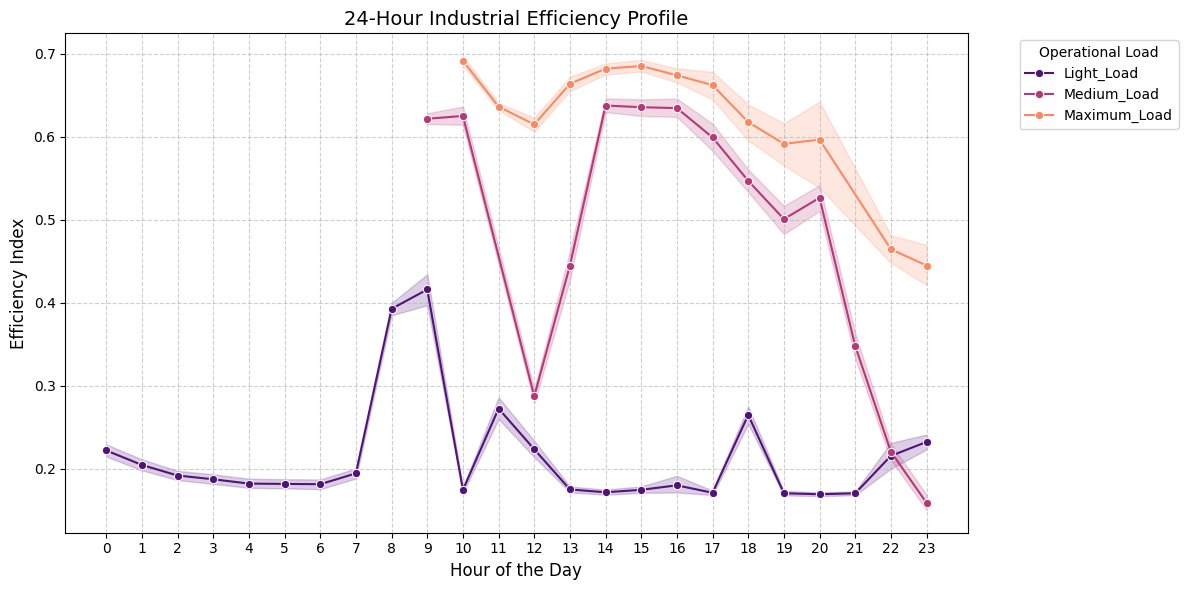

In [12]:
# HOURLY EFFICIENCY PROFILE

plt.figure(figsize=(12, 6))

# Using a lineplot to show how efficiency fluctuates throughout the day
# hue='Load_Type' allows us to see if efficiency drops during specific shifts
sns.lineplot(data=df, x='Hour', y='Efficiency_Index', hue='Load_Type', palette='magma', marker='o')

plt.title('24-Hour Industrial Efficiency Profile', fontsize=14)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Efficiency Index', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Operational Load', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Look for dips in the Efficiency Index during 'Light Load' periods which may indicate high standby power waste.

### **The Industrial Risk Matrix To discretize continuous efficiency data into actionable performance cohorts**

 High-level metrics like "Efficiency Index" are numerically accurate but operationally difficult for non-technical stakeholders to interpret. To drive change in the factory, we must categorize performance into clear "Risk Zones." To solve this Utilizing **Quantile-based Discretization** (`pd.qcut`) to rank every 15-minute interval into four cohorts: Critical, Poor, Good, and Excellent and developing a **Normalized Heatmap Matrix** to visualize the intersection of Load Type and Efficiency Performance.
* **Finding:** This matrix reveals the "Efficiency Floor." We can now quantify exactly what percentage of "Maximum Load" operations are achieving "Excellent" status versus how often "Light Load" operations fall into the "Critical" zone.


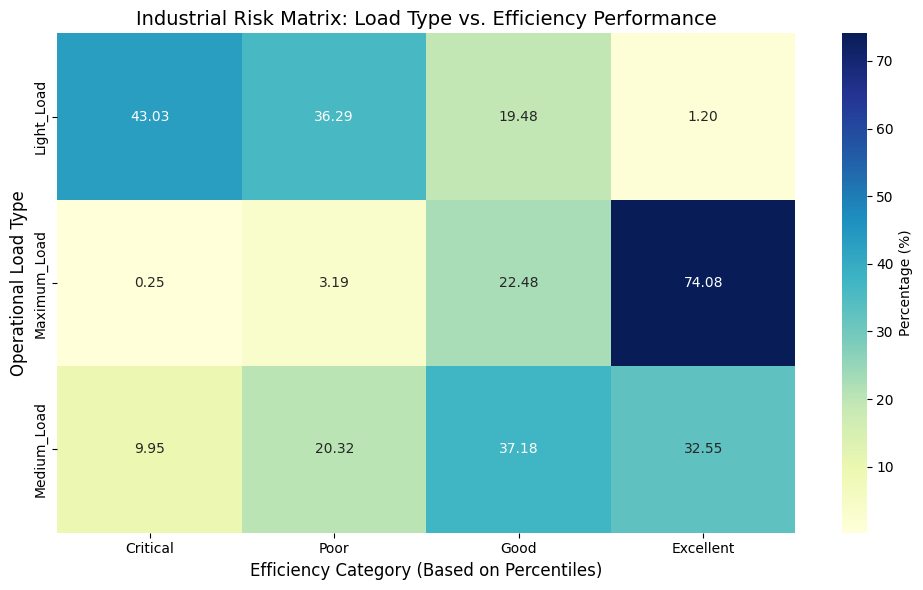


--- DATA AUDIT & ANALYSIS COMPLETE ---
Final Dataset Shape: (35040, 20)
Final Column List: ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2_tCO2', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Month', 'Day_of_Week', 'Is_Weekend', 'Total_Reactive_Waste', 'Efficiency_Index', 'Carbon_Intensity', 'Is_Peak_Event', 'Efficiency_Rank']


In [13]:
# OUR FINAL INDUSTRIAL RISK MATRIX

# Discretize Efficiency into Categories (Technique: Percentiles/Quantiles)
# This transforms a float into an actionable 'Rank'
df['Efficiency_Rank'] = pd.qcut(df['Efficiency_Index'], q=4,
                                labels=['Critical', 'Poor', 'Good', 'Excellent'])

# Create the Cross-Analysis (Technique: Normalized Crosstabulation)
# This shows the percentage distribution of efficiency ranks within each Load Type
efficiency_impact = pd.crosstab(df['Load_Type'], df['Efficiency_Rank'], normalize='index') * 100

# Generating the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(efficiency_impact, annot=True, cmap='YlGnBu', fmt='.2f',
            cbar_kws={'label': 'Percentage (%)'})

plt.title('Industrial Risk Matrix: Load Type vs. Efficiency Performance', fontsize=14)
plt.xlabel('Efficiency Category (Based on Percentiles)', fontsize=12)
plt.ylabel('Operational Load Type', fontsize=12)

# Adjusting layout to prevent clipping of labels
plt.tight_layout()
plt.show()

print("\n--- DATA AUDIT & ANALYSIS COMPLETE ---")
print(f"Final Dataset Shape: {df.shape}")
print("Final Column List:", df.columns.tolist())

### **Multi-Dimensional Correlation Matrix To quantify the linear relationships between raw sensor data and engineered efficiency metrics**

 In an industrial power system, variables like Reactive Power and CO2 emission are deeply interconnected. Without a Correlation Matrix, we cannot tell if an improvement in one area (e.g., reducing Lagging Current) will have a meaningful impact on the overall **Efficiency Index**. We apply Constructing a **Correlation Heatmap** using only numeric features and a **Triangular Mask** to eliminate redundant data and improve visual clarity.
* **Key Goal:** To identify the "Drivers of Waste." By looking at the correlation between `Total_Reactive_Waste` and `Efficiency_Index`, we can statistically prove the financial impact of power factor issues.
* This cell provides the mathematical "Evidence" used to justify the recommendations in the Final Summary.

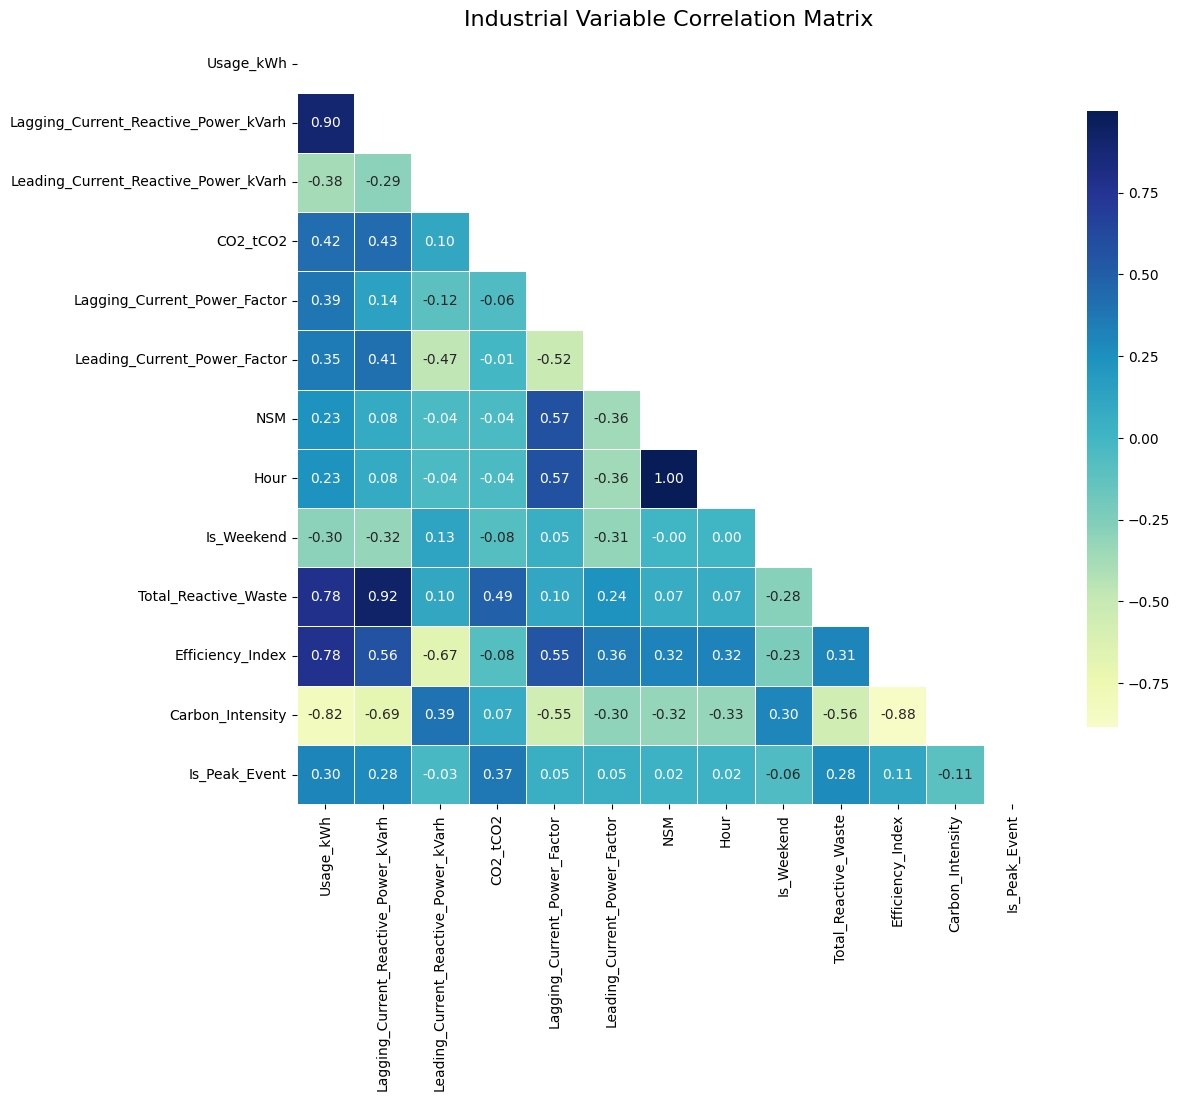


--- INSIGHT CHECK ---
High positive values (near 1.0) show variables that increase together.
High negative values (near -1.0) show variables that move in opposite directions.


In [14]:
# MULTI-DIMENSIONAL CORRELATION ANALYSIS
# We include our engineered features to see how they relate to raw sensor data
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Creating the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='YlGnBu',
            center=0, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Industrial Variable Correlation Matrix', fontsize=16)
plt.show()

print("\n--- INSIGHT CHECK ---")
print("High positive values (near 1.0) show variables that increase together.")
print("High negative values (near -1.0) show variables that move in opposite directions.")